# Precificação de Opções: Modelo Black-Scholes e Simulação de Monte Carlo
**Autor:** Fernando Ecumbi  
**Data:** 16 de Maio de 2023  
**Disciplina/Projeto:** Engenharia Financeira / Avaliação de Derivativos

---

### Resumo do Projeto
Este notebook apresenta a implementação analítica do modelo **Black-Scholes-Merton (BSM)** e a validação numérica através da **Simulação de Monte Carlo** para opções de compra europeias (*Call Options*).


### Black-Scholes-Merton (BSM) Fórmula Analítica

O preço de uma call europeia($C$) é:


$$C = S_0 N(d_1) - K e^{-rT} N(d_2)$$


Onde os componentes $d_1$ e $d_2$ are são definidos como:
    

$$d_1 = \frac{\ln(S_0 / K) + (r + \frac{\sigma^2}{2})T}{\sigma \sqrt{T}}$$

$$d_2 = \frac{\ln(S_0 / K) + (r - \frac{\sigma^2}{2})T}{\sigma \sqrt{T}}$$

$$d_2 = d_1 - \sigma \sqrt{T}$$


<br>

### Variáveis do Modelo Black-Scholes-Merton

As variáveis utilizadas na fórmula são:


| Símbolo | Variável | Descrição |
| :--- | :--- | :--- |
| $S_0$ | **Preço do Ativo** | Preço atual da ação |
| $K$ | **Preço de Exercício** | Preço definido para a compra |
| $T$ | **Tempo** | Tempo até o vencimento (expresso em fração de ano) |
| $r$ | **Taxa Livre de Risco** | Taxa de juros anualizada |
| $\sigma$ | **Volatilidade** | Desvio padrão anualizado dos retornos do ativo ($\sigma$) |
| $N(x)$ | **Distribuição Normal** | Função de densidade acumulada da normal padrão |
<br><br>

1. **$N(d_1)$ (O Delta):** 
   - Representa a sensibilidade do preço da opção em relação ao preço da ação. 
   - Se o Delta é 0.60, para cada Kwz 1,00 que o ativo adjacente sobe, a opção sobe Kwz 0,60.
    <br>
2. **$N(d_2)$ (Probabilidade de Exercício):** 
   - É a probabilidade (no mundo neutro ao risco) de a opção terminar "no dinheiro" (*In-the-Money*) na data de vencimento.
    <br>
3. **$S_0 N(d_1)$:** 
   - O valor esperado do que você recebe (ativo adjacente) se exercer a opção.
    <br>
4. **$K e^{-rT} N(d_2)$:** 
   - O valor presente do custo que você terá que pagar (o preço de exercício $K$) se a opção for exercida.
    
    <br>
**Resumo:** O preço da Call é a diferença entre o que você espera **receber** (ativo adjacente) e o que você espera **pagar** (o Strike), ambos trazidos a valor presente.




In [1]:
def valor_chamada_bsm(S0, k, T, r, sigma):
    """ A avaliação de uma opção de compra europeia (Call) no modelo Black-Scholes-Merton (BSM)
    Fórmula Analítica.
    
    Parametro
    ==========
    S0 : float
         Preço atual do ativo subjacente
    k : float
        Preço de exercício da opção
    T : float
        Tempo até o vencimento expresso em anos
    r : float
        Taxa de juros livre de risco anualizada
    sigma : float 
        Volatilidade anualizada do retorno do ativo
        
    Resultado
    =======
    valor : float
        Valor presente da opção de compra
    
    """
    
    from math import log, sqrt, exp
    import numpy as np
    from scipy import stats
    
    d1 = (np.log(S0 / k) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - (sigma * np.sqrt(T))
    
    valor = (S0 * stats.norm.cdf(d1, 0.0, 1.0) 
             - k * np.exp(-r * T) * stats.norm.cdf(d2, 0.0, 1.0))
    # stats,norm,cdf --> Função de Distribuição Acumulada            
    
    return valor

In [2]:
def calc_sensib_vega(S0, k, T, sigma):
    """ Medindo a Sensibilidade: Vega modelo..
    
    Parametro
    ==========
    S0 : float
         Preço atual do ativo subjacente
    k : float
        Preço de exercício da opção
    T : float
        Tempo até o vencimento expresso em anos
    r : float
        Taxa de juros livre de risco anualizada
    sigma : float 
        Volatilidade anualizada do retorno do ativo
        
    Resultado
    =======
    vega : float
        Derivada em Relação à Volatilidade sigma, i.e. vega
    """
    
    from math import log, sqrt
    from scipy import stats
    
    S0 = float(S0)
    d1 = (log(S0/k)+(r - 0.5*sigma **2)*T/(sigma * sqrt(T)))
    vega = S0 * stats.norm.pdf(d1, 0.0, 1.0)* sqrt(T)
     #  stats,norm,pdf --> Função de Densidade de Probabilidade  
    
    return vega
    

### Medindo a Sensibilidade: Vega ($\nu$)

**Vega ($\nu$):** Representa a variação no prêmio da opção para cada mudança de 1% na volatilidade implícita ($\sigma$). O Vega mede a sensibilidade do preço da opção em relação a mudanças na volatilidade.

* **Fórmula Analítica:** 
  $$\nu = S_0 N'(d_1) \sqrt{T}$$

* **Interpretação:** Se uma opção tem um Vega de 0.15, isso significa que para cada aumento de 1% na volatilidade implícita, o preço da opção deve aumentar aproximadamente Kwz 0,15 (mantendo os outros fatores constantes).

* **Ponto de Máximo:** O Vega é maior quando a opção está **"No Dinheiro" (At-the-Money)** e diminui à medida que a opção se move para muito dentro ou muito fora do dinheiro.


In [3]:
def calc_vol_implic(S0, k, T, r, sigma_est, it=100):
    """ Volatilidade implícita de uma opção de compra europeia (Call) no modelo Black-Scholes-Merton (BSM).
    
    Parametro
    ==========
    S0 : float
         Preço atual do ativo subjacente
    k : float
        Preço de exercício da opção
    T : float
        Tempo até o vencimento expresso em anos
    r : float
        Taxa de juros livre de risco anualizada
    sigma_est : float 
            Volatilidade implícita estimada 
        
    Resultado
    =======
    sigma_est : float
        Volatilidade implícita estimada numérica
    
    """
    
    for i in range(it):
        sigma_est -= ((valor_chamada_bsm(S0, K, T, r, sigma_est) - C0)
                      /calc_sensib_vega(S0, k, T, r, sigma_est))
        
        
        return sigma_est

### Métodos Numéricos para Cálculo da Volatilidade Implícita (IV)

Como a volatilidade ($\sigma$) não pode ser isolada algebricamente na fórmula de Black-Scholes, utilizamos algoritmos de busca de raízes para encontrar o valor de $\sigma$ que iguala o preço do modelo ao preço de mercado ($C_{BSM}(\sigma) - C_{mercado} = 0$).

Os principais métodos são:

1. **Método de Newton-Raphson:**
   - É o mais rápido e comum. Ele utiliza o **Vega** ($\nu$) da opção (que é a derivada do preço em relação à volatilidade) para convergir rapidamente.
   - **Fórmula de Iteração:** $\sigma_{n+1} = \sigma_n - \frac{C(\sigma_n) - C_{mercado}}{Vega(\sigma_n)}$

2. **Método da Bisseção:**
   - Mais lento, porém extremamente robusto. Ele "encurrala" a volatilidade entre um limite inferior (ex: 0%) e um superior (ex: 500%) e vai dividindo o intervalo ao meio até encontrar o valor correto.

3. **Método de Brent:**
   - Um algoritmo híbrido que combina a bisseção com a interpolação quadrática inversa. É o método padrão utilizado por bibliotecas como `scipy.optimize` por ser rápido e raramente falhar na convergência.

4. **Busca de Grade (Grid Search):**
   - Menos eficiente; testa diversos valores de $\sigma$ em uma lista pré-definida até encontrar o mais próximo.


In [4]:
# Exemplo de Cadeia de Opções (Option Chain) para Simulação

import numpy as np
import pandas as pd

# 1. Parâmetros de Entrada (Input Data)
S0 = 100.0          # Preço atual do ativo 
T = 1.0            # Tempo até o vencimento (1 ano)
r = 0.05           # Taxa livre de risco (5% ao ano)
sigma = 0.20       # Volatilidade anualizada (20%)

# Criando diferentes Preço de exercício para ver como o preço da Call e o Delta mudam
k = np.linspace(80, 120, 9) # Preço de exercício de 80 a 120

df_simulacao = pd.DataFrame({
    'Preço de exercício (K)': k,
    'Preço atual do ativo (S0)': S0,
    'Tempo (T)': T,
    'Taxa (r)': r,
    'Vol (sigma)': sigma
})

print("Dados prontos para simulação:")
display(df_simulacao)


Dados prontos para simulação:


,Preço de exercício (K),Preço atual do ativo (S0),Tempo (T),Taxa (r),Vol (sigma)
0,80.0,100.0,1.0,0.05,0.2
1,85.0,100.0,1.0,0.05,0.2
2,90.0,100.0,1.0,0.05,0.2
3,95.0,100.0,1.0,0.05,0.2
4,100.0,100.0,1.0,0.05,0.2
5,105.0,100.0,1.0,0.05,0.2
6,110.0,100.0,1.0,0.05,0.2
7,115.0,100.0,1.0,0.05,0.2
8,120.0,100.0,1.0,0.05,0.2


In [5]:
Valor_da_chamada = valor_chamada_bsm(S0, k, T, r, sigma)
Valor_da_chamada

array([24.58883544, 20.46928792, 16.69944841, 13.34646495, 10.45058357,
        8.02135224,  6.04008813,  4.46657915,  3.24747742])

### Avaliação por Monte Carlo (Simulação)
A simulação de Monte Carlo é um método numérico que estima o valor de uma opção ao simular milhares de caminhos possíveis para o preço do ativo subjacente até a data de vencimento.

#### 1. Lógica Matemática
Assumimos que o preço da ação segue um **Movimento Browniano Geométrico (GBM)**. O preço no vencimento ($S_T$) é calculado como:

$$S_T = S_0 \exp\left( (r - \frac{1}{2} \sigma^2) T + \sigma \sqrt{T} z \right)$$

Onde:
*   $z$ é uma variável aleatória da distribuição normal padrão $N(0,1)$.
*   $r$ é a taxa livre de risco (drift).
*   $\sigma$ é a volatilidade anualizada.

#### 2. Passos da Simulação
Para cada iteração (caminho simulado):
1.  Geramos um número aleatório $z$.
2.  Calculamos o preço final da ação $S_T$.
3.  Determinamos o **Payoff** da opção no vencimento: $\max(S_T - K, 0)$.
4.  Acumulamos o valor para calcular a média.

#### 3. Resultado Final
O preço da opção é a **média de todos os payoffs** simulados, descontada a valor presente pela taxa livre de risco:

$$C \approx e^{-rT} \frac{1}{n} \sum_{i=1}^{n} Payoff_i$$

---
*Nota: Diferente do modelo analítico BSM, o resultado do Monte Carlo é estocástico e converge para o valor real à medida que aumentamos o número de iterações.*


In [6]:
from time import time
from math import exp, sqrt, log
from random import gauss, seed


seed(20000) # semente
t0 = time()

S0 = 100.
k = 105.
T = 1.0
r = 0.05
sigma = 0.2

M = 50 # número de passos de tempo 

dt = T/M # Comprimento do Intervalo de Tempo
I = 250000 # Número de Caminhos 

# Matriz para armazenar todos os caminhos
caminhos = []
for i in range(I):
    trajetoria = []
    for t in range(M+1):
        if t == 0:
            trajetoria.append(S0)
        else:
            z = gauss(0.0, 1.0)
            # Calcula o próximo preço baseado no último da lista
            St = trajetoria[t - 1]*exp((r-0.5*sigma**2)*dt
                              + sigma*sqrt(dt)*z)
            
            trajetoria.append(St)
    caminhos.append(trajetoria)
    
# Calcula o valor presente
C0 = exp(-r*T)*sum([max(trajetoria[-1] - k,0) for trajetoria in caminhos])/I

# `resultados
tpy = time() - t0
print("Valor da Opção Europeia via Monte Carlo %7.3f"%C0)
print("Medindo a Duração da Simulação (Segundos) %7.3f"%tpy)


Valor da Opção Europeia via Monte Carlo   7.999
Medindo a Duração da Simulação (Segundos)  28.602


In [7]:
# Calcula a média dos payoffs e traz a valor presente
media_payoff = 0.0
for path in caminhos:
    media_payoff+= max(path[-1] -k,0)
C0 = exp(-r*T)*media_payoff/I
print("Valor da Opção Europeia via Monte Carlo:",round(C0,3))

Valor da Opção Europeia via Monte Carlo: 7.999


### Visualização das Trajetórias de Preço

A visualização gráfica nos permite observar o comportamento estocástico (aleatório) do ativo subjacente ao longo do tempo. 

**O que o gráfico representa:**
*   **Linhas Coloridas:** Cada linha é um caminho único e independente que o preço da ação tomou durante a simulação.
*   **Eixo X (Passos):** Representa a progressão do tempo de $0$ até o vencimento $T$.
*   **Eixo Y (Preço):** O valor do ativo em cada passo.
*   **Linha do Preço de exercício ($K$):** Geralmente plotamos uma linha horizontal para identificar quais caminhos terminaram "No Dinheiro" (acima da linha para uma Call).

*Nota: Plotamos apenas uma amostra (ex: 50 caminhos) para que o gráfico permaneça legível, já que plotar 100.000 linhas deixaria o sistema lento.*


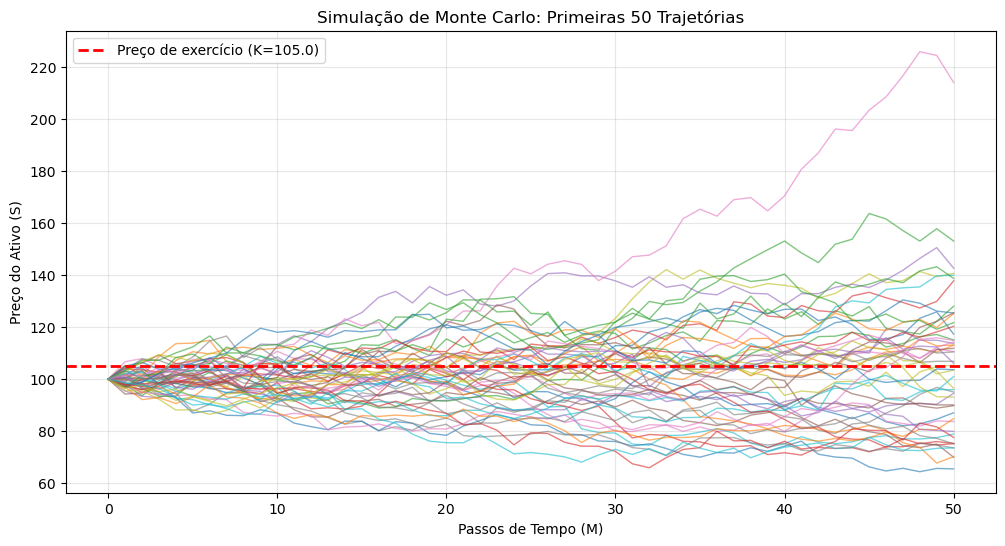

In [8]:
import matplotlib.pyplot as plt

# 1. Definir quantos caminhos mostrar (ex: os primeiros 100)
num_caminhos_plot = 50

plt.figure(figsize=(12, 6))

# 2. Plotar as trajetórias
for i in range(min(num_caminhos_plot, len(caminhos))):
    plt.plot(caminhos[i], lw=1, alpha=0.6)

# 3. Adicionar a linha do Strike Price (K) para referência
plt.axhline(y=k, color='red', linestyle='--', linewidth=2, label=f'Preço de exercício (K={k})')

# 4. Formatação do gráfico
plt.title(f"Simulação de Monte Carlo: Primeiras {num_caminhos_plot} Trajetórias")
plt.xlabel("Passos de Tempo (M)")
plt.ylabel("Preço do Ativo (S)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Estados da Opção (Moneyness)

Ao observar o gráfico das trajetórias, podemos classificar o resultado final de cada caminho comparando o preço no vencimento ($S_T$) com o preço de exercício ($K$):

1.  **ATM (At-the-Money - No Dinheiro):**
    *   Ocorre quando $S_T \approx K$.
    *   No gráfico, são os caminhos que terminam exatamente em cima da linha vermelha do *Preço de exercício*.
    *   O valor intrínseco é zero, mas a opção está no limiar de ganho.
    <br>
2.  **OTM (Out-of-the-Money - Fora do Dinheiro):**
    *   Ocorre quando $S_T < K$ (para uma Call).
    *   No gráfico, são todas as trajetórias que terminam **abaixo** da linha vermelha.
    *   O payoff nestes casos é **zero**. O titular não exerce o direito de compra.
    <br>
3.  **ITM (In-the-Money - Dentro do Dinheiro):**
    *   Ocorre quando $S_T > K$ (para uma Call).
    *   No gráfico, são as trajetórias que terminam **acima** da linha vermelha.
    *   Apenas estes caminhos contribuem para o valor final da opção via Monte Carlo.


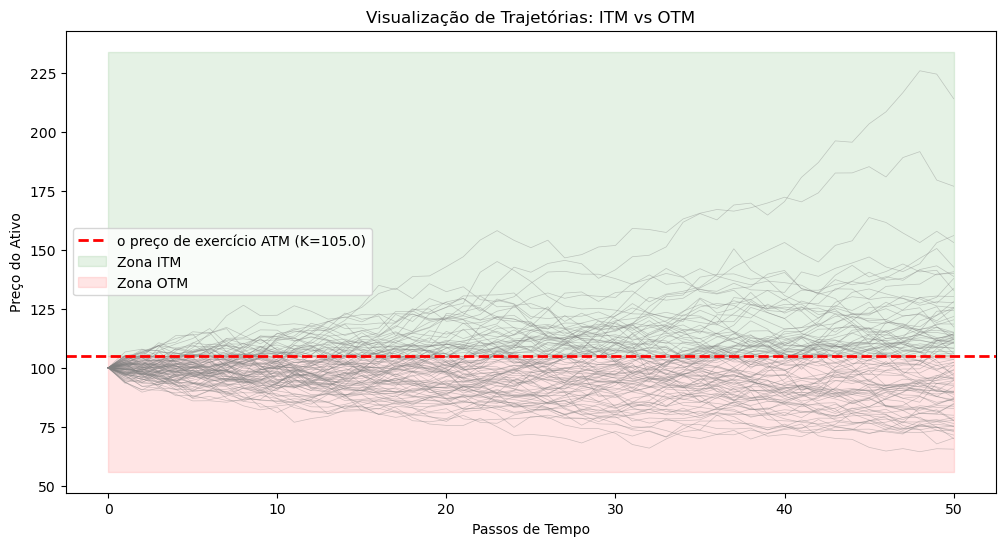

In [9]:
import matplotlib.pyplot as plt

num_caminhos_plot = 100
plt.figure(figsize=(12, 6))

# Plotar caminhos
for i in range(min(num_caminhos_plot, len(caminhos))):
    plt.plot(caminhos[i], lw=0.5, alpha=0.4, color='gray')

# Linha do Strike (K) - O divisor entre ITM e OTM
plt.axhline(y=k, color='red', linestyle='--', linewidth=2, label=f'o preço de exercício ATM (K={k})')

# Colorir as zonas
plt.fill_between(range(M + 1), k, plt.gca().get_ylim()[1], color='green', alpha=0.1, label='Zona ITM')
plt.fill_between(range(M + 1), plt.gca().get_ylim()[0], k, color='red', alpha=0.1, label='Zona OTM')

plt.title("Visualização de Trajetórias: ITM vs OTM")
plt.xlabel("Passos de Tempo")
plt.ylabel("Preço do Ativo")
plt.legend()
plt.show()
